# 06 — Hyperparameter and family multiplicity (Section 5.7)

**Purpose:** One notebook for thesis Section 5.7: (1) **family decomposition** — main structural analysis; (2) **secondary** unique-value HP decomposition on predictions $P$ (robustness / appendix); (3) **descriptive meta-models** on $V_m$ — main tool for HP importance and range-style summaries (with out-of-sample validation and importance stability); plus hotspot deltas and seed aggregation.

**Pipeline:** Canonical model-level table → family aggregates → secondary HP aggregates → meta-model suite → plots. Configuration lives in ``HPAnalysisConfig`` (`analysis/hp_section57.py`).


## Imports and path setup


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.hp_analysis import (
    POOL_TYPE_FULL_POOL,
    POOL_TYPE_RASHOMON,
    select_pool_indices,
)
from analysis.hp_meta_model import run_hp_meta_model_suite
from analysis.hp_section57 import (
    HPAnalysisConfig,
    aggregate_hp_seed_tables,
    build_canonical_model_analysis_exports,
    collect_multiseed_hp_tables,
    export_per_dataset_wide_tables,
    export_seed_aggregates_and_hotspot_delta,
    resolve_meta_seed_column,
)
from analysis.hp_notebook_plots import (
    plot_meta_importance_and_stability_grids,
    plot_meta_interaction_tiles,
    plot_meta_pdp_tiles,
    plot_pool_compare_grid,
    plot_vm_vs_brier_grids,
)
from analysis.hp_multiplicity_pipeline import (
    plot_decomp_hp_bars,
    plot_decomp_hp_grid_rashomon,
    plot_family_importance_bars,
    plot_hotspot_hp_delta,
    plot_hotspot_hp_delta_grid,
    plot_family_importance_compare_bars,
    plot_vm_hp_compare_bars,
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb06")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## Configuration (Section 5.7)

All tunables live in ``HPAnalysisConfig``. Notebook aliases below keep downstream cells readable.


In [2]:
cfg = HPAnalysisConfig(
    results_dir=RESULTS_DIR,
    table_dir=TABLE_DIR,
    fig_dir=FIG_DIR,
)

# Backwards-compatible names for later cells
DATASETS = list(cfg.datasets)
POOL_TYPES = list(cfg.pool_types)
K_EACH = cfg.rashomon_k_each
TOP_HP = cfg.top_hp
MIN_HH_OBS = cfg.min_hh_obs
ILLUSTRATE_SEED = cfg.illustrate_seed


## Stage 1 — Canonical model-level table (multi-seed)

Build ``df_models`` and per-seed wide tables, export per-dataset CSV slices, and write the canonical model-level analysis table used by meta-models.


In [3]:
_tables = collect_multiseed_hp_tables(cfg)
df_models = _tables["models"]
df_metrics_long = _tables["metrics_long"]
df_decomp_hp = _tables["decomp_hp_wide"]
df_vm_hp = _tables["vm_hp_wide"]

export_per_dataset_wide_tables(_tables, cfg)
build_canonical_model_analysis_exports(df_models, cfg.table_dir)

print("Rows:", {k: len(v) for k, v in [
    ("models", df_models),
    ("metrics_long", df_metrics_long),
    ("decomp_hp", df_decomp_hp),
    ("vm_hp", df_vm_hp),
]})


Saved hp_model_level_analysis_table.csv and hp_model_level_analysis_summary.csv
Rows: {'models': 11250, 'metrics_long': 6392, 'decomp_hp': 3027, 'vm_hp': 3027}


## Optional: single-seed illustration


In [4]:
if ILLUSTRATE_SEED is not None and not df_vm_hp.empty:
    show = df_vm_hp[df_vm_hp["seed"] == ILLUSTRATE_SEED].sort_values(
        ["dataset", "family", "ratio_of_sums"], ascending=[True, True, False]
    )
    display(show.head(40))
else:
    print("Set ILLUSTRATE_SEED to an integer to preview one seed (optional).")


Set ILLUSTRATE_SEED to an integer to preview one seed (optional).


## Stages 2–3 — Aggregates: family (main) and secondary HP decompositions

Family importance on all / HH / non-HH is the **main** structural summary. Unique-value HP decompositions on $P$ and $V_m$-by-HP-value paths are **secondary** (appendix / robustness) and feed hotspot-delta tables where needed.


In [5]:
_aggs = aggregate_hp_seed_tables(df_metrics_long, df_decomp_hp, df_vm_hp)
df_fam_agg = _aggs["fam_agg"]
df_decomp_agg = _aggs["decomp_agg"]
df_vm_agg = _aggs["vm_agg"]
delta_seed = _aggs["delta_seed"]
df_delta_agg = _aggs["delta_agg"]

export_seed_aggregates_and_hotspot_delta(_aggs, cfg)


In [6]:
# Family importance: full_pool vs Rashomon
if not df_fam_agg.empty and "pool_type" in df_fam_agg.columns:
    for ds in DATASETS:
        sub = df_fam_agg[(df_fam_agg["dataset"] == ds) & (df_fam_agg["subset"] == "all")].copy()
        if not sub.empty:
            sub.to_csv(TABLE_DIR / f"family_importance_full_vs_rashomon_{ds}.csv", index=False)

# V_m-based HP importance: full_pool vs Rashomon
if not df_vm_agg.empty and "pool_type" in df_vm_agg.columns:
    for (ds, fam), grp in df_vm_agg[df_vm_agg["subset"] == "all"].groupby(["dataset", "family"]):
        grp.to_csv(TABLE_DIR / f"hp_importance_full_vs_rashomon_{ds}_{fam}.csv", index=False)

# decomposition-based HP importance: full_pool vs Rashomon
if not df_decomp_agg.empty and "pool_type" in df_decomp_agg.columns:
    for (ds, fam), grp in df_decomp_agg[df_decomp_agg["subset"] == "all"].groupby(["dataset", "family"]):
        grp.to_csv(TABLE_DIR / f"decomp_hp_importance_full_vs_rashomon_{ds}_{fam}.csv", index=False)

In [7]:
# Compact V_m-based full-pool vs Rashomon summary tables (subset = all)

if not df_vm_agg.empty and "pool_type" in df_vm_agg.columns:
    _cmp_vm = df_vm_agg[df_vm_agg["subset"] == "all"].copy()

    for (ds, fam), grp in _cmp_vm.groupby(["dataset", "family"]):
        piv = (
            grp.pivot_table(
                index=["dataset", "family", "subset", "hp_name"],
                columns="pool_type",
                values=["mean_importance", "mean_rank"],
                aggfunc="first",
            )
            .reset_index()
        )

        piv.columns = [
            "_".join([str(x) for x in c if str(x) != ""]).strip("_")
            if isinstance(c, tuple) else c
            for c in piv.columns
        ]

        req = [
            "mean_importance_Rashomon",
            "mean_importance_full_pool",
            "mean_rank_Rashomon",
            "mean_rank_full_pool",
        ]
        if not all(c in piv.columns for c in req):
            continue

        out = piv.rename(
            columns={
                "mean_importance_Rashomon": "rashomon_mean_importance",
                "mean_importance_full_pool": "full_pool_mean_importance",
                "mean_rank_Rashomon": "rashomon_mean_rank",
                "mean_rank_full_pool": "full_pool_mean_rank",
            }
        ).copy()

        out["delta_rashomon_minus_full"] = (
            out["rashomon_mean_importance"] - out["full_pool_mean_importance"]
        )

        out = out.sort_values(
            ["delta_rashomon_minus_full", "rashomon_mean_importance"],
            ascending=[False, False],
        )

        out.to_csv(
            TABLE_DIR / f"hp_compare_summary_{ds}_{fam}.csv",
            index=False,
        )

        out.head(5).to_csv(
            TABLE_DIR / f"hp_compare_summary_top5_{ds}_{fam}.csv",
            index=False,
        )

print("Saved compact full-pool vs Rashomon HP comparison summaries.")

Saved compact full-pool vs Rashomon HP comparison summaries.


In [8]:
# Compact tables: meta-model top drivers (``hp_top2_driver_summary.csv`` from meta-model block)
# and COMPAS hotspot deltas (decomposition-based secondary analysis).

# COMPAS hotspot delta extremes (Rashomon)
if not df_delta_agg.empty and "pool_type" in df_delta_agg.columns:
    d_comp = df_delta_agg[
        (df_delta_agg["dataset"] == "compas")
        & (df_delta_agg["pool_type"] == POOL_TYPE_RASHOMON)
    ].copy()
    if not d_comp.empty and "family" in d_comp.columns:
        rows = []
        for fam, grp in d_comp.groupby("family"):
            i_max = grp["mean_delta"].idxmax()
            i_min = grp["mean_delta"].idxmin()
            r_max = grp.loc[i_max]
            r_min = grp.loc[i_min]
            n_seeds = int(grp["n_seeds"].max()) if "n_seeds" in grp.columns else np.nan
            rows.append(
                {
                    "Family": fam,
                    "Most increased in HH": f"{r_max['hp']} (mean_delta={r_max['mean_delta']:.4f})",
                    "Most decreased in HH": f"{r_min['hp']} (mean_delta={r_min['mean_delta']:.4f})",
                    "n_seeds": n_seeds,
                }
            )
        hp_hot = pd.DataFrame(rows).sort_values("Family")
        out_hot = TABLE_DIR / "hp_hotspot_delta_compas_compact.csv"
        hp_hot.to_csv(out_hot, index=False)
        print("Saved", out_hot)
        print(hp_hot.to_string(index=False))
    else:
        print("No rows for hp_hotspot_delta_compas_compact.")
else:
    print("Skipping hp_hotspot_delta_compas_compact.")


Saved C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_hotspot_delta_compas_compact.csv
Family                   Most increased in HH                    Most decreased in HH  n_seeds
   GBM          subsample (mean_delta=0.0266)       n_estimators (mean_delta=-0.0094)       10
LogReg                 C (mean_delta=-0.0016)           l1_ratio (mean_delta=-0.0040)       10
   MLP learning_rate_init (mean_delta=0.0475) hidden_layer_sizes (mean_delta=-0.0024)       10
    RF  min_samples_split (mean_delta=0.0062)          max_depth (mean_delta=-0.0399)       10
   kNN                  p (mean_delta=0.0067)            weights (mean_delta=-0.0651)       10


In [9]:
# Hyperparameter coverage diagnostic: how many seeds contributed to each aggregated HP row

coverage_parts = []

# V_m-based HP coverage
if not df_vm_agg.empty:
    cols_needed = [
        c for c in [
            "dataset",
            "family",
            "subset",
            "pool_type",
            "hp_name",
            "n_seeds",
            "mean_importance",
            "std_importance",
            "mean_rank",
        ]
        if c in df_vm_agg.columns
    ]
    if cols_needed:
        vm_cov = df_vm_agg[cols_needed].copy()
        vm_cov["importance_type"] = "V_m"
        vm_cov = vm_cov.rename(columns={"hp_name": "hp"})
        coverage_parts.append(vm_cov)

# decomposition-based HP coverage
if not df_decomp_agg.empty:
    cols_needed = [
        c for c in [
            "dataset",
            "family",
            "subset",
            "pool_type",
            "hp",
            "n_seeds",
            "mean_importance",
            "std_importance",
            "mean_rank",
        ]
        if c in df_decomp_agg.columns
    ]
    if cols_needed:
        decomp_cov = df_decomp_agg[cols_needed].copy()
        decomp_cov["importance_type"] = "decomposition"
        coverage_parts.append(decomp_cov)

if coverage_parts:
    hp_coverage = pd.concat(coverage_parts, ignore_index=True)

    # sort so problematic rows (few contributing seeds) appear first
    sort_cols = [c for c in ["n_seeds", "dataset", "family", "subset", "pool_type", "importance_type", "hp"] if c in hp_coverage.columns]
    hp_coverage = hp_coverage.sort_values(sort_cols, ascending=[True] + [True] * (len(sort_cols) - 1))

    hp_coverage.to_csv(TABLE_DIR / "hp_coverage_diagnostic.csv", index=False)

    # optional: save only potentially problematic rows
    if "n_seeds" in hp_coverage.columns:
        low_cov = hp_coverage[hp_coverage["n_seeds"] < 10].copy()
        if not low_cov.empty:
            low_cov.to_csv(TABLE_DIR / "hp_coverage_low_seed_rows.csv", index=False)

    print("Saved HP coverage diagnostics.")
else:
    print("No HP coverage rows to save.")

Saved HP coverage diagnostics.


In [10]:
# Hotspot-vs-all delta summary tables (decomposition-based)
# mean_delta > 0  => more important in HH than in all
# mean_delta < 0  => less important in HH than in all

if not df_delta_agg.empty:
    _delta_sum = df_delta_agg.copy()

    # Optional: if you mainly care about Rashomon for thesis writing, keep this filter.
    # Comment it out if you want both pool types exported.
    # if "pool_type" in _delta_sum.columns:
    #     _delta_sum = _delta_sum[_delta_sum["pool_type"] == POOL_TYPE_RASHOMON].copy()

    group_cols = [c for c in ["dataset", "family", "pool_type"] if c in _delta_sum.columns]

    if group_cols:
        for keys, grp in _delta_sum.groupby(group_cols):
            if isinstance(keys, tuple):
                key_map = dict(zip(group_cols, keys))
            else:
                key_map = {group_cols[0]: keys}

            ds = key_map.get("dataset", "unknown")
            fam = key_map.get("family", "unknown")
            pt = key_map.get("pool_type", "unknown")

            # keep useful columns only if present
            cols_keep = [
                c for c in [
                    "dataset",
                    "family",
                    "pool_type",
                    "hp",
                    "mean_delta",
                    "std_delta",
                    "mean_rank",
                    "rank_freq_top1",
                    "rank_freq_top3",
                    "n_seeds",
                ]
                if c in grp.columns
            ]

            out = grp[cols_keep].copy()

            # sort by largest positive delta first
            if "mean_delta" in out.columns:
                out = out.sort_values("mean_delta", ascending=False)

            safe_pt = str(pt).replace(" ", "_")

            out.to_csv(
                TABLE_DIR / f"hp_hotspot_delta_summary_{ds}_{fam}_{safe_pt}.csv",
                index=False,
            )

            # top positive shifts
            if "mean_delta" in out.columns:
                top_inc = out[out["mean_delta"] > 0].head(5).copy()
                if not top_inc.empty:
                    top_inc.to_csv(
                        TABLE_DIR / f"hp_hotspot_delta_top_increase_{ds}_{fam}_{safe_pt}.csv",
                        index=False,
                    )

                # top negative shifts
                top_dec = out.sort_values("mean_delta", ascending=True)
                top_dec = top_dec[top_dec["mean_delta"] < 0].head(5).copy()
                if not top_dec.empty:
                    top_dec.to_csv(
                        TABLE_DIR / f"hp_hotspot_delta_top_decrease_{ds}_{fam}_{safe_pt}.csv",
                        index=False,
                    )

        print("Saved hotspot-vs-all HP delta summary tables.")
    else:
        print("No grouping columns available for hotspot delta summaries.")
else:
    print("No hotspot delta rows to save.")

Saved hotspot-vs-all HP delta summary tables.


In [11]:
# Explicit Rashomon - full_pool effect-size tables for V_m-based HP importance (subset = all)

if not df_vm_agg.empty and "pool_type" in df_vm_agg.columns:
    _delta_vm = df_vm_agg[df_vm_agg["subset"] == "all"].copy()

    for (ds, fam), grp in _delta_vm.groupby(["dataset", "family"]):
        piv = (
            grp.pivot_table(
                index=["dataset", "family", "subset", "hp_name"],
                columns="pool_type",
                values=["mean_importance", "mean_rank", "std_importance", "n_seeds"],
                aggfunc="first",
            )
            .reset_index()
        )

        piv.columns = [
            "_".join([str(x) for x in c if str(x) != ""]).strip("_")
            if isinstance(c, tuple) else c
            for c in piv.columns
        ]

        req = [
            "mean_importance_Rashomon",
            "mean_importance_full_pool",
        ]
        if not all(c in piv.columns for c in req):
            continue

        out = piv.rename(
            columns={
                "mean_importance_Rashomon": "rashomon_mean_importance",
                "mean_importance_full_pool": "full_pool_mean_importance",
                "mean_rank_Rashomon": "rashomon_mean_rank",
                "mean_rank_full_pool": "full_pool_mean_rank",
                "std_importance_Rashomon": "rashomon_std_importance",
                "std_importance_full_pool": "full_pool_std_importance",
                "n_seeds_Rashomon": "rashomon_n_seeds",
                "n_seeds_full_pool": "full_pool_n_seeds",
            }
        ).copy()

        out["delta_rashomon_minus_full"] = (
            out["rashomon_mean_importance"] - out["full_pool_mean_importance"]
        )
        out["abs_delta"] = out["delta_rashomon_minus_full"].abs()

        # full table sorted by absolute difference
        out_all = out.sort_values(
            ["abs_delta", "delta_rashomon_minus_full"],
            ascending=[False, False],
        ).copy()

        out_all.to_csv(
            TABLE_DIR / f"hp_importance_delta_{ds}_{fam}.csv",
            index=False,
        )

        # strongest Rashomon-specific HPs
        out_r = out[out["delta_rashomon_minus_full"] > 0].copy()
        if not out_r.empty:
            out_r = out_r.sort_values(
                "delta_rashomon_minus_full", ascending=False
            ).head(5)
            out_r.to_csv(
                TABLE_DIR / f"hp_importance_delta_top_rashomon_{ds}_{fam}.csv",
                index=False,
            )

        # strongest full-pool-specific HPs
        out_f = out[out["delta_rashomon_minus_full"] < 0].copy()
        if not out_f.empty:
            out_f = out_f.sort_values(
                "delta_rashomon_minus_full", ascending=True
            ).head(5)
            out_f.to_csv(
                TABLE_DIR / f"hp_importance_delta_top_fullpool_{ds}_{fam}.csv",
                index=False,
            )

    print("Saved explicit Rashomon-vs-full-pool HP effect-size tables.")
else:
    print("No V_m HP rows available for Rashomon-vs-full-pool delta export.")

Saved explicit Rashomon-vs-full-pool HP effect-size tables.


In [12]:
# Canonical model-level exports are produced in Stage 1 (`build_canonical_model_analysis_exports`).
pass


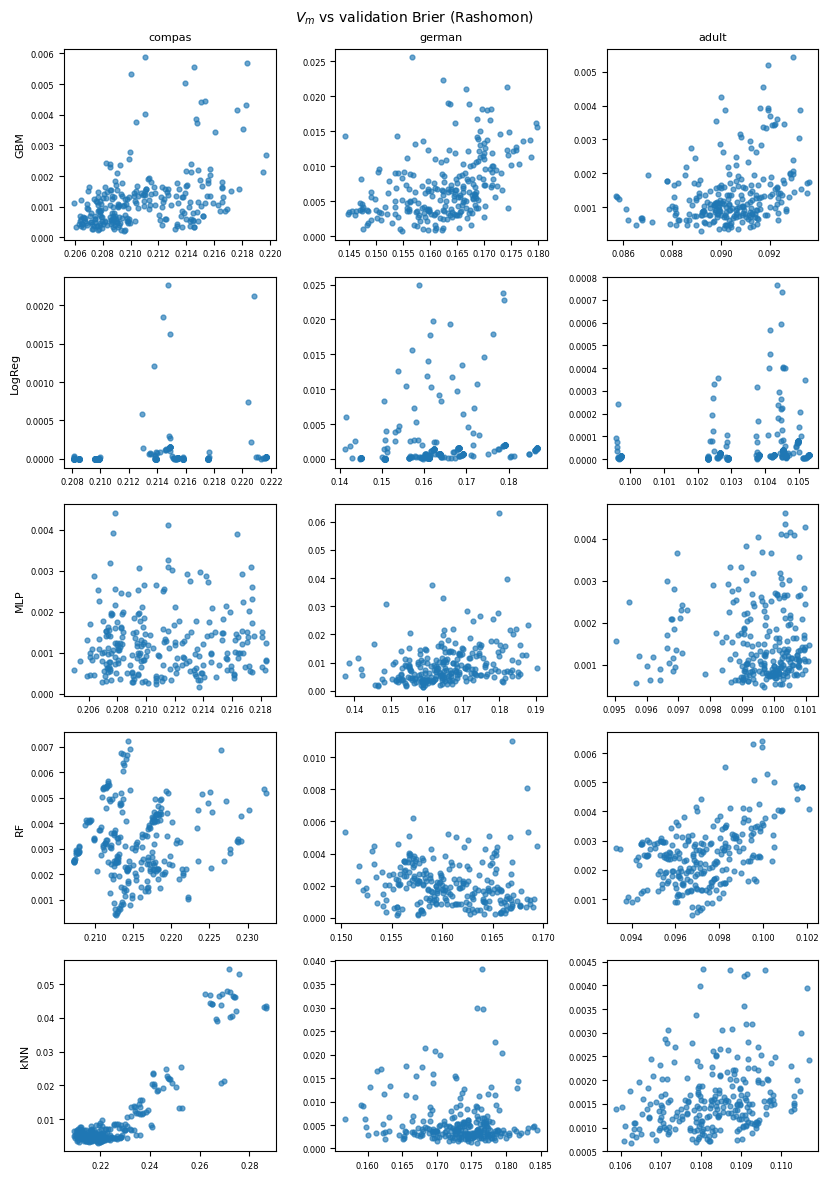

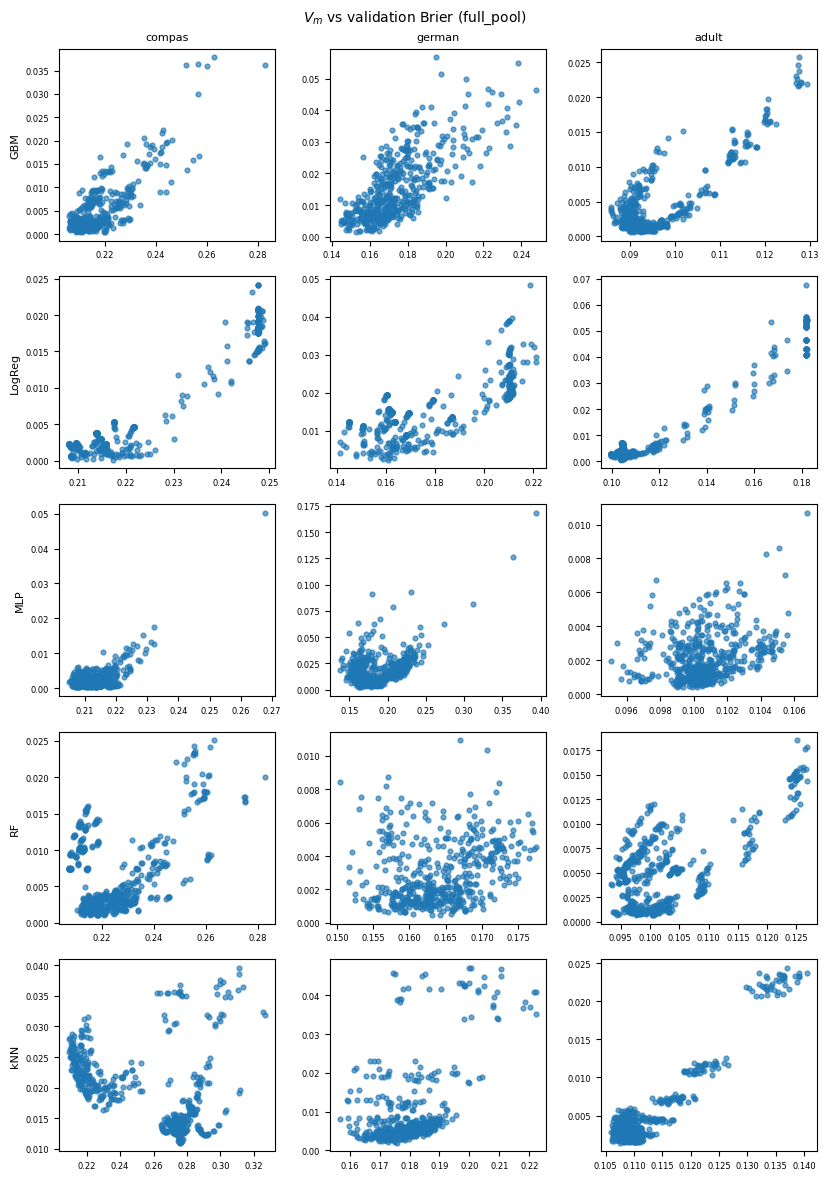

Saved hp_vm_vs_performance_grid_*.pdf (+ per-panel PDFs).
Saved hp_vm_vs_performance_summary.csv


In [13]:
# Stage: $V_m$ vs validation Brier — overview grids + per-panel PDFs
from analysis.hp_notebook_plots import plot_vm_vs_brier_grids

if not df_models.empty:
    perf_df = df_models.copy()
    perf_col = None
    for col in ["validation_brier", "val_brier", "brier_val", "brier_score"]:
        if col in perf_df.columns:
            perf_col = col
            break
    if perf_col is None:
        print("No validation-performance column for scatter grids.")
    elif "V_m" not in perf_df.columns:
        print("No V_m column.")
    else:
        rows = []
        group_cols = [x for x in ["dataset", "family", "pool_type"] if x in perf_df.columns]
        for keys, grp in perf_df.groupby(group_cols):
            key_map = dict(zip(group_cols, keys)) if isinstance(keys, tuple) else {group_cols[0]: keys}
            ds, fam, pt = key_map.get("dataset"), key_map.get("family"), key_map.get("pool_type")
            g = grp[[perf_col, "V_m"] + [x for x in ["V_m_HH", "V_m_nonHH"] if x in grp.columns]].dropna()
            if len(g) < 3:
                continue
            row = {
                "dataset": ds,
                "family": fam,
                "pool_type": pt,
                "n_models": len(g),
                "pearson_corr_validation_brier_vs_Vm": g[perf_col].corr(g["V_m"], method="pearson"),
                "spearman_corr_validation_brier_vs_Vm": g[perf_col].corr(g["V_m"], method="spearman"),
                "mean_validation_brier": g[perf_col].mean(),
                "std_validation_brier": g[perf_col].std(),
                "mean_Vm": g["V_m"].mean(),
                "std_Vm": g["V_m"].std(),
            }
            if "V_m_HH" in g.columns:
                row["pearson_corr_validation_brier_vs_Vm_HH"] = g[perf_col].corr(g["V_m_HH"], method="pearson")
            if "V_m_nonHH" in g.columns:
                row["pearson_corr_validation_brier_vs_Vm_nonHH"] = g[perf_col].corr(g["V_m_nonHH"], method="pearson")
            rows.append(row)
        if rows:
            perf_summary = pd.DataFrame(rows).sort_values(["dataset", "family", "pool_type"])
            perf_summary.to_csv(TABLE_DIR / "hp_vm_vs_performance_summary.csv", index=False)
            plot_vm_vs_brier_grids(perf_df, perf_col=perf_col, fig_dir=FIG_DIR)
            print("Saved hp_vm_vs_performance_summary.csv")
        else:
            print("No grouped rows for performance scatter.")
else:
    print("No df_models for performance scatter.")


In [14]:
# Stage 4 — Descriptive meta-models on $V_m$ (main HP importance / conditional ranges)
# Exploratory RandomForest: leave-one-seed-out (prefer ``outer_seed``) or row KFold fallback; bootstrap importance stability; PDP-style effect CSVs.

if not df_models.empty:
    _seed_col = resolve_meta_seed_column(df_models, cfg.seed_column_preference)
    run_hp_meta_model_suite(
        df_models,
        table_dir=cfg.table_dir,
        fig_dir=cfg.fig_dir,
        n_stability_reps=cfg.meta_stability_reps,
        random_state=cfg.meta_random_state,
        seed_col=_seed_col,
    )
    print(
        "Meta-model stage: hp_meta_model_summary.csv, grouped importances, "
        "stability (top1_frequency / top3_frequency / mean_rank), effect CSVs, hp_top2_driver_summary."
    )
else:
    print("No model rows for meta-model stage.")


Meta-model stage: hp_meta_model_summary.csv, grouped importances, stability (top1_frequency / top3_frequency / mean_rank), effect CSVs, hp_top2_driver_summary.


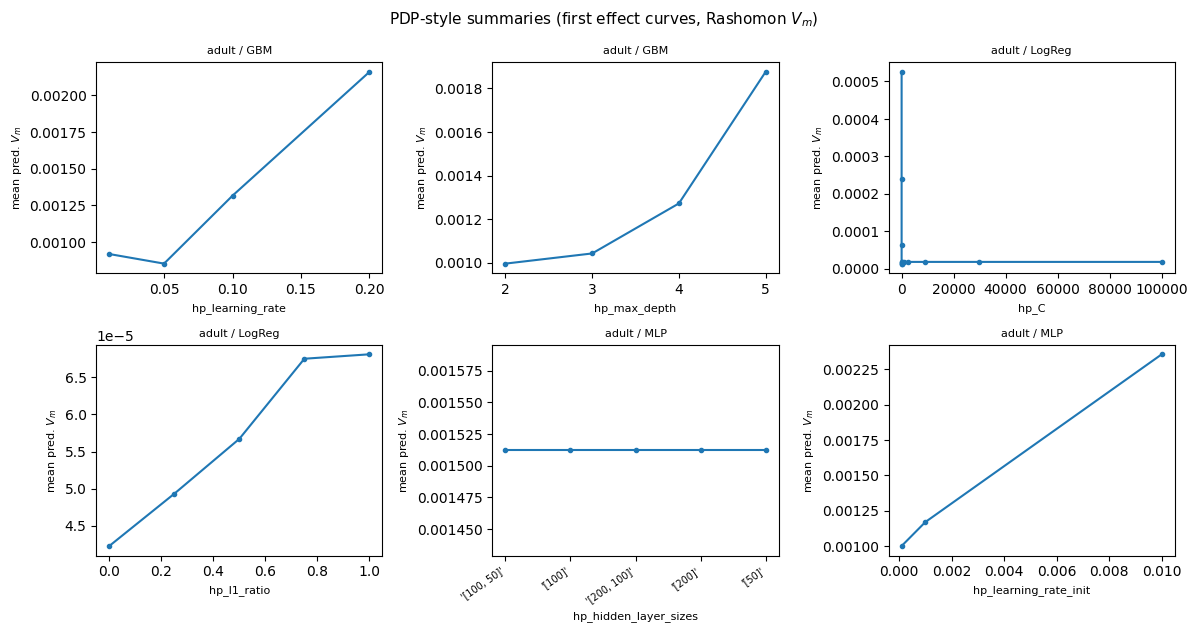

Saved hp_meta_pdp_tiles_overview.pdf and 6 hp_meta_pdp_*.pdf panels.


In [15]:
# PDP-style curves: one tiled overview + per-feature PDFs (thesis can cite specific paths)
from analysis.hp_notebook_plots import plot_meta_pdp_tiles

if not df_models.empty:
    plot_meta_pdp_tiles(table_dir=TABLE_DIR, fig_dir=FIG_DIR, max_panels=6)
else:
    print("No df_models for PDP tiles.")


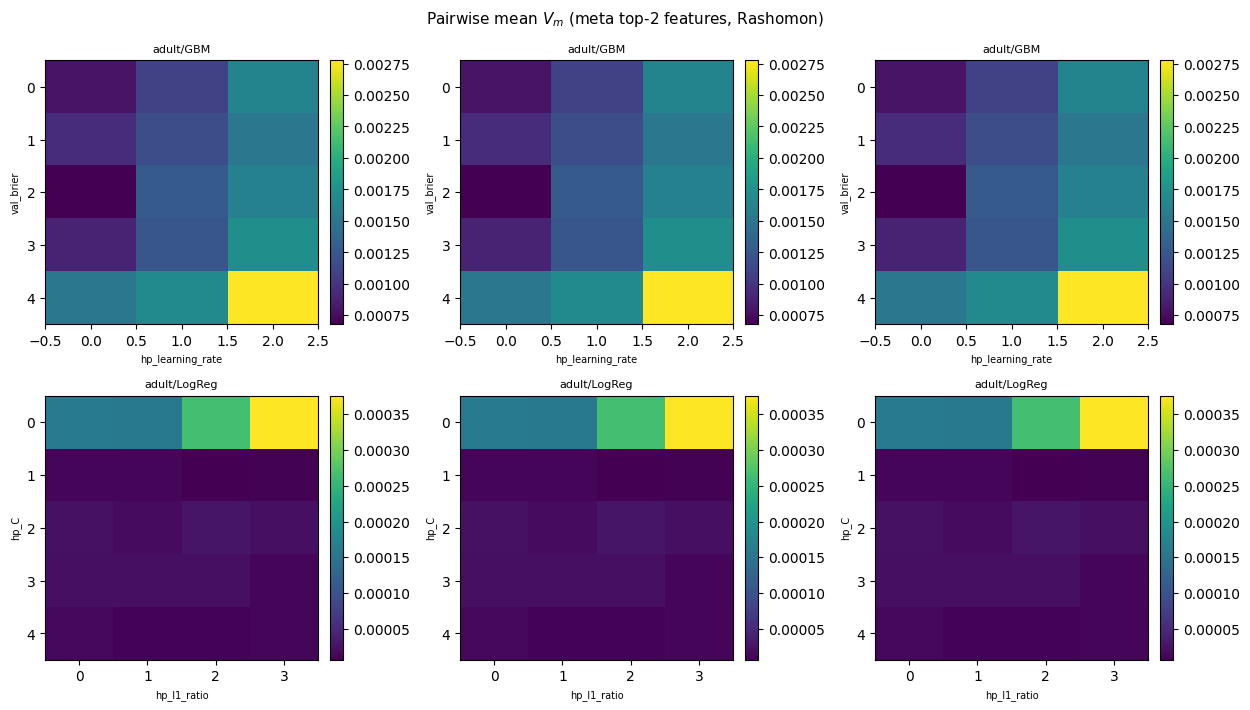

Saved hp_meta_interaction_tiles_overview.pdf (+ one standalone).


In [16]:
# Pairwise mean $V_m$: tiled overview + one standalone PDF
from analysis.hp_notebook_plots import plot_meta_interaction_tiles

if not df_models.empty:
    meta_summary_path = TABLE_DIR / "hp_meta_model_summary.csv"
    if meta_summary_path.exists():
        meta_summary = pd.read_csv(meta_summary_path)
        interaction_df = df_models.copy()
        hp_cols = sorted([c for c in interaction_df.columns if c.startswith("hp_")])

        def resolve_feat(name):
            if pd.isna(name):
                return None
            if name == "validation_brier":
                for col in ["validation_brier", "val_brier", "brier_val", "brier_score"]:
                    if col in interaction_df.columns:
                        return col
            if name in hp_cols:
                return name
            return None

        plot_meta_interaction_tiles(
            interaction_df,
            meta_summary,
            fig_dir=FIG_DIR,
            hp_cols=hp_cols,
            resolve_feat=resolve_feat,
            max_panels=6,
        )
    else:
        print("hp_meta_model_summary.csv not found.")
else:
    print("No data for interaction analysis.")


## Family importance (mean ± std over seeds)


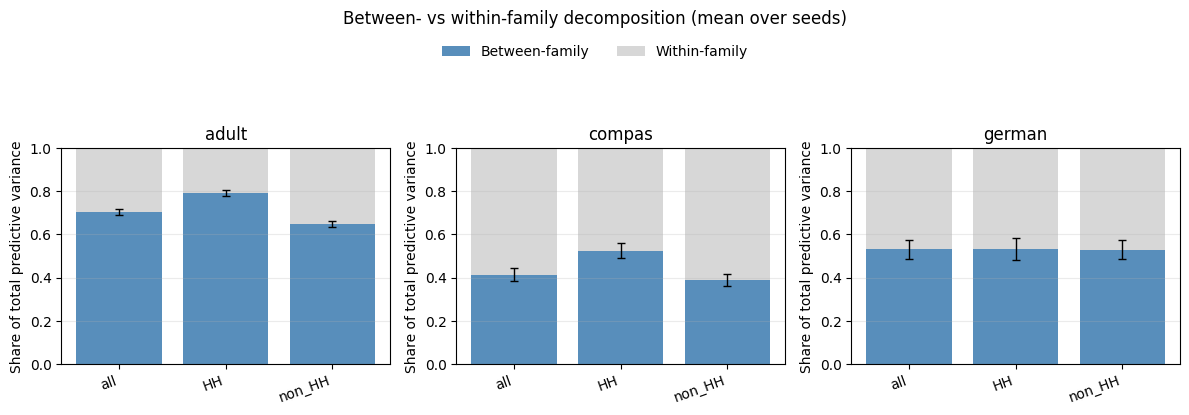

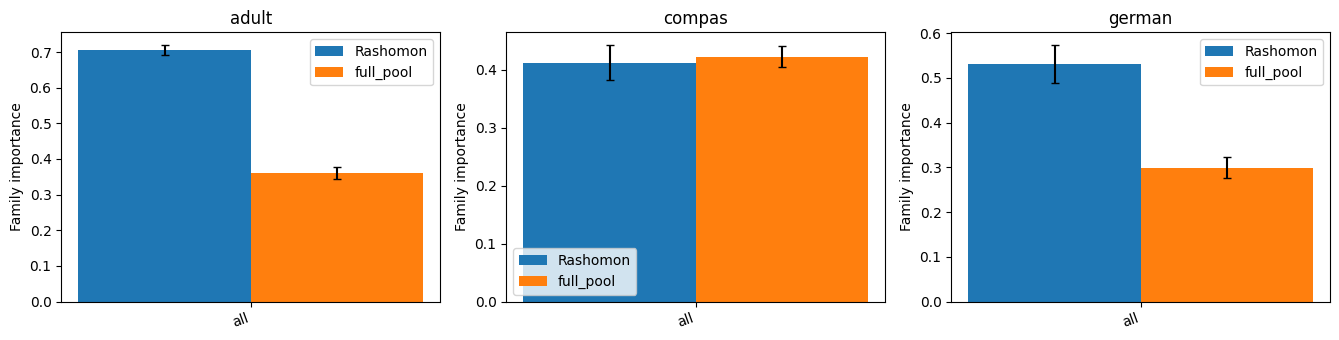

In [44]:
if not df_fam_agg.empty:
    fam_rash = df_fam_agg[df_fam_agg["pool_type"] == POOL_TYPE_RASHOMON].copy()
    plot_family_importance_bars(
        fam_rash,
        fig_path=FIG_DIR / "family_importance_agg_rashomon.pdf",
    )
else:
    print("No family-importance rows.")

if not df_fam_agg.empty and "pool_type" in df_fam_agg.columns:
    plot_family_importance_compare_bars(
        df_fam_agg[df_fam_agg["subset"] == "all"].copy(),
        fig_path=FIG_DIR / "family_importance_compare_all.pdf",
    )


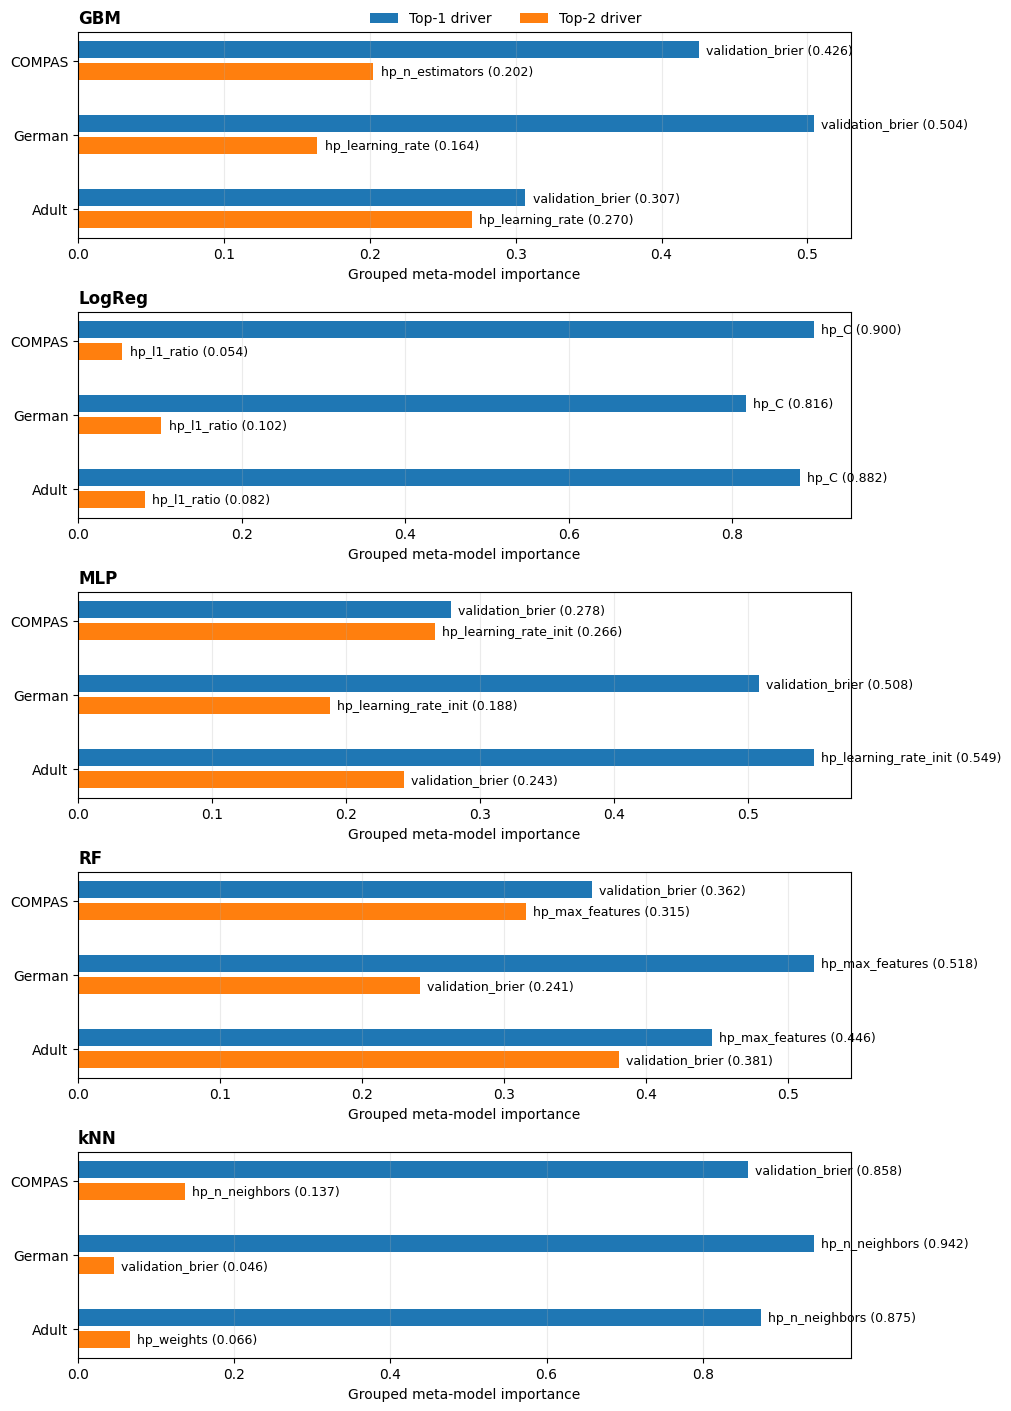

Saved C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\figures\nb06\hp_top2_driver_grid_rashomon.pdf


In [18]:
# Top-2 meta-model hyperparameter drivers (grouped importance, Rashomon, V_m)

meta_path = TABLE_DIR / "hp_meta_model_summary.csv"
if meta_path.exists():
    ms = pd.read_csv(meta_path)
    pool_ok = ms["pool_type"] == POOL_TYPE_RASHOMON if "pool_type" in ms.columns else True
    tgt_ok = ms["target_vm"] == "V_m" if "target_vm" in ms.columns else True
    top2_plot = ms[pool_ok & tgt_ok].copy()
else:
    top2_plot = pd.DataFrame()

if not top2_plot.empty:
    dataset_order = ["compas", "german", "adult"]
    family_order = ["GBM", "LogReg", "MLP", "RF", "kNN"]
    pretty_dataset = {"compas": "COMPAS", "german": "German", "adult": "Adult"}

    fig, axes = plt.subplots(
        nrows=len(family_order),
        ncols=1,
        figsize=(10, 14),
        constrained_layout=True,
        sharex=False,
    )
    if len(family_order) == 1:
        axes = [axes]

    for ax, fam in zip(axes, family_order):
        sub = top2_plot[top2_plot["family"] == fam].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        y_positions = []
        widths = []
        labels = []
        rank_labels = []
        base_positions = {"compas": 6, "german": 3, "adult": 0}
        offsets = {1: 0.45, 2: -0.45}

        for ds in dataset_order:
            rdf = sub[sub["dataset"] == ds]
            if rdf.empty:
                continue
            r = rdf.iloc[0]
            for rank, impcol, namecol in (
                (1, "top_feature_1_importance", "top_feature_1"),
                (2, "top_feature_2_importance", "top_feature_2"),
            ):
                if pd.isna(r.get(namecol)):
                    continue
                y = base_positions[ds] + offsets[rank]
                y_positions.append(y)
                widths.append(float(r[impcol]) if pd.notna(r.get(impcol)) else 0.0)
                labels.append(f"{r[namecol]} ({r[impcol]:.3f})")
                rank_labels.append(f"Top-{rank}")

        if not y_positions:
            ax.set_visible(False)
            continue

        bar_colors = ["C0" if lab == "Top-1" else "C1" for lab in rank_labels]
        ax.barh(y_positions, widths, height=0.7, color=bar_colors)
        max_w = max(widths) if widths else 1.0
        for y, w, txt in zip(y_positions, widths, labels):
            ax.text(w + 0.01 * max_w, y, txt, va="center", fontsize=9)
        ax.set_yticks([6, 3, 0])
        ax.set_yticklabels([pretty_dataset[d] for d in dataset_order], fontsize=10)
        ax.set_title(fam, loc="left", fontsize=12, fontweight="bold")
        ax.set_xlabel("Grouped meta-model importance", fontsize=10)
        ax.grid(axis="x", alpha=0.25)

    from matplotlib.patches import Patch

    handles = [
        Patch(facecolor="C0", label="Top-1 driver"),
        Patch(facecolor="C1", label="Top-2 driver"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
    out_path = FIG_DIR / "hp_top2_driver_grid_rashomon.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved", out_path)
else:
    print("No rows for top-2 HP driver plot (meta-model summary missing or empty).")


## V_m-based within-family HP importance (subset = all)


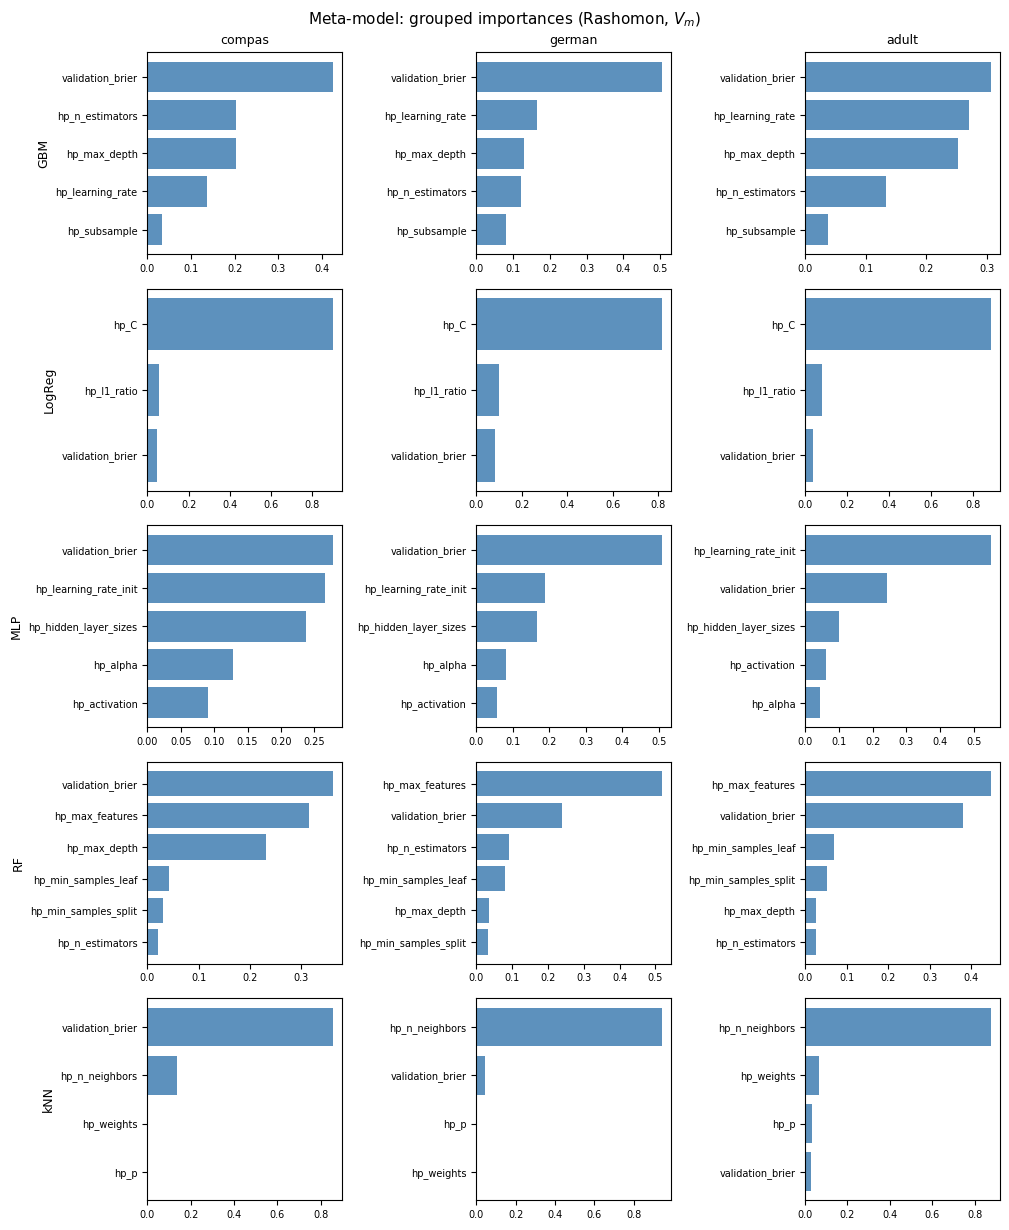

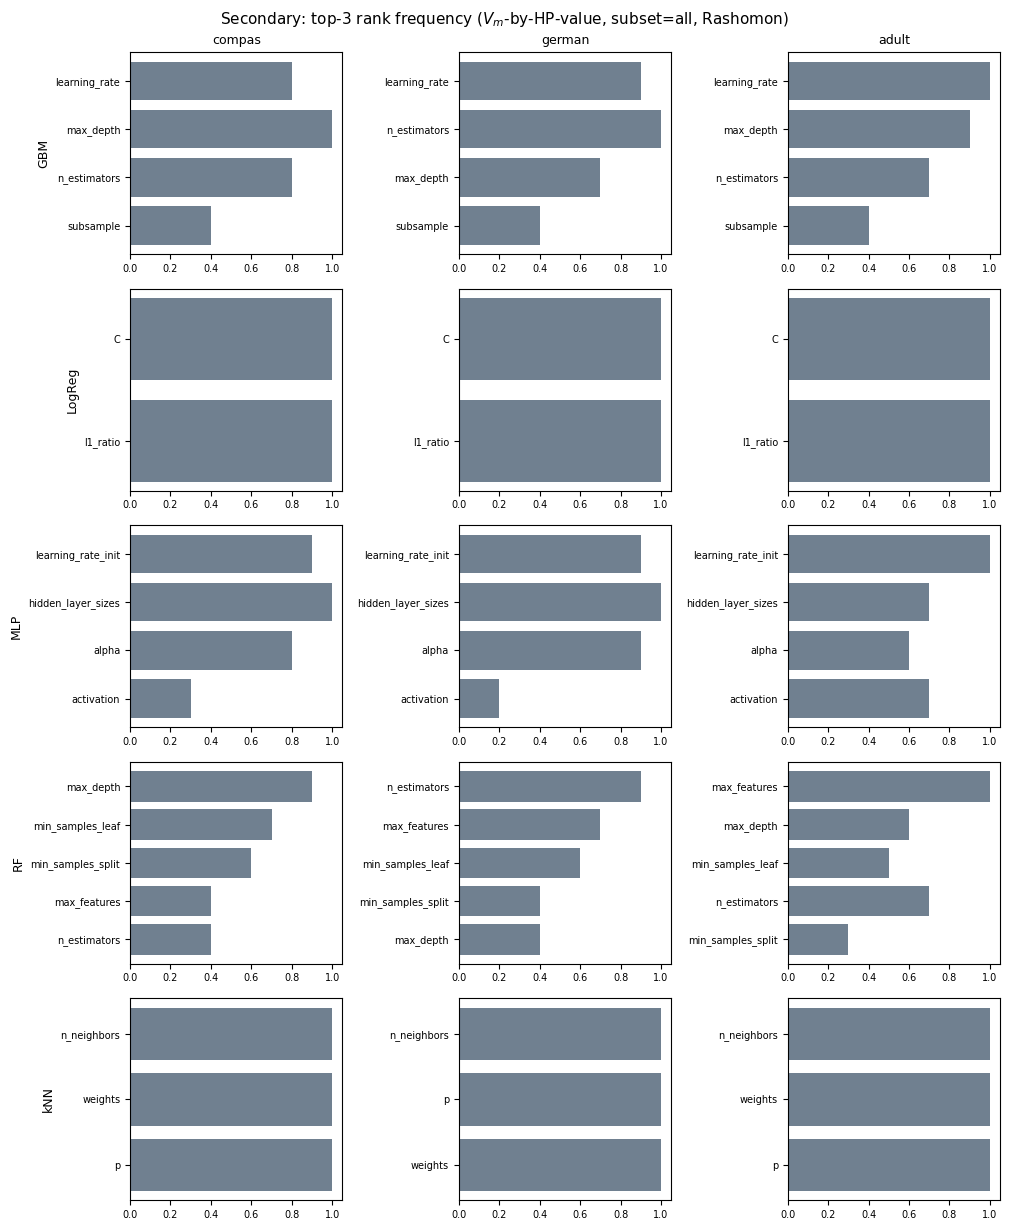

Saved grids: hp_meta_importance_bar_rashomon_grid.pdf hp_rank_stability_rashomon_grid.pdf


In [19]:
# Meta-model importance + (secondary) rank stability: two overview grids + per-(dataset,family) PDFs
from analysis.hp_notebook_plots import plot_meta_importance_and_stability_grids

plot_meta_importance_and_stability_grids(
    table_dir=TABLE_DIR,
    fig_dir=FIG_DIR,
    df_vm_agg=df_vm_agg,
    top_hp=TOP_HP,
)


## Rank stability (V_m-based, top HPs per family)


In [20]:
# Rank stability figures are merged with meta-model importance (previous cell).
pass


## Decomposition-based within-family HP (subset = all)


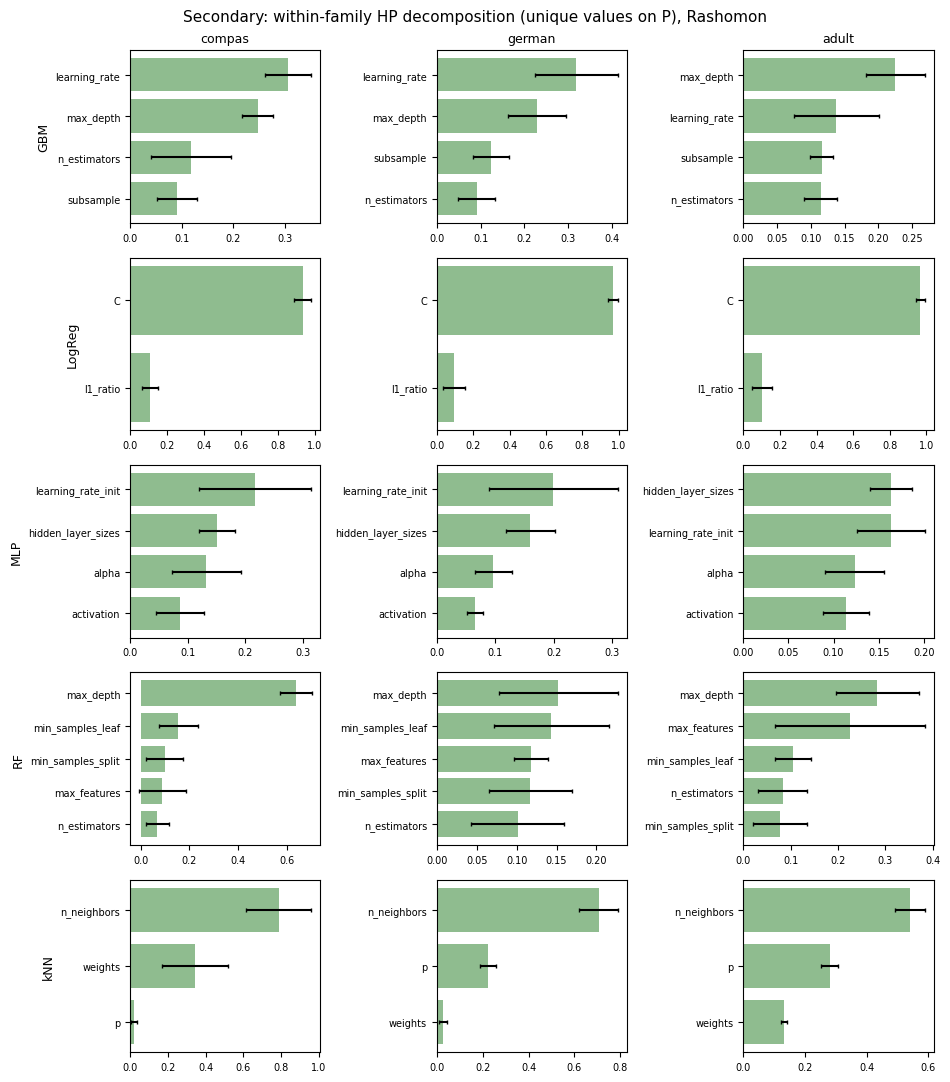

In [21]:
# Secondary decomposition: per-family PDFs (no pop-up) + one Rashomon overview grid
decomp_all = pd.DataFrame()
if not df_decomp_agg.empty:
    decomp_all = df_decomp_agg[df_decomp_agg["subset"] == "all"].copy()
    if "pool_type" in decomp_all.columns:
        decomp_all = decomp_all[decomp_all["pool_type"] == POOL_TYPE_RASHOMON]
if not decomp_all.empty:
    for (ds, fam), _ in decomp_all.groupby(["dataset", "family"]):
        plot_decomp_hp_bars(
            decomp_all,
            dataset=ds,
            subset="all",
            family=fam,
            top_n=TOP_HP,
            fig_path=FIG_DIR / f"decomp_hp_secondary_bar_rashomon_{ds}_{fam}.pdf",
            show=False,
        )
    plot_decomp_hp_grid_rashomon(
        decomp_all,
        datasets=DATASETS,
        families=["GBM", "LogReg", "MLP", "RF", "kNN"],
        subset="all",
        top_n=min(TOP_HP, 8),
        fig_path=FIG_DIR / "decomp_hp_secondary_bar_rashomon_grid.pdf",
        show=True,
    )
else:
    print("No decomposition HP aggregates for secondary bar charts.")


## Hotspot vs all (decomposition HP delta)


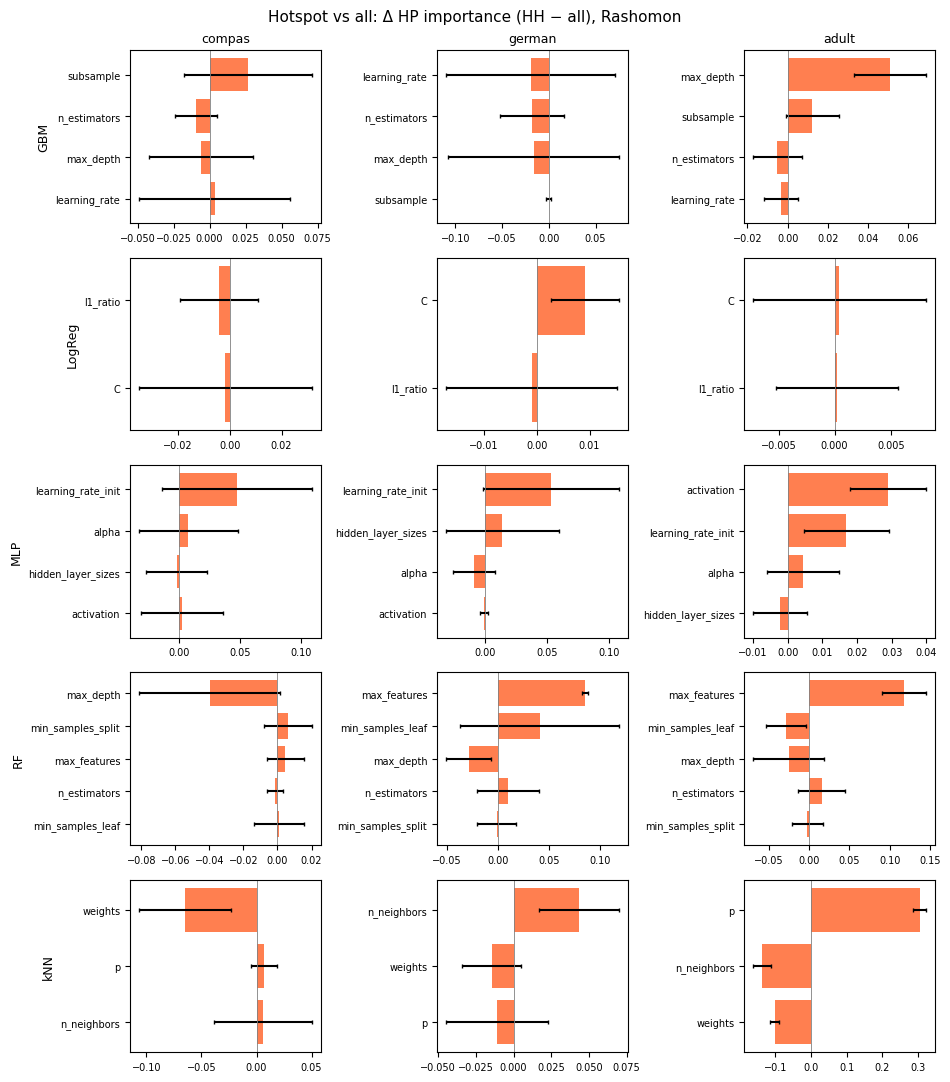

In [22]:
# Hotspot deltas: per-family PDFs (no pop-up) + one overview grid
_ddel = df_delta_agg.copy()
if not _ddel.empty and "pool_type" in _ddel.columns:
    _ddel = _ddel[_ddel["pool_type"] == POOL_TYPE_RASHOMON]
if not _ddel.empty:
    for (ds, fam), _ in _ddel.groupby(["dataset", "family"]):
        plot_hotspot_hp_delta(
            _ddel,
            dataset=ds,
            family=fam,
            top_n=TOP_HP,
            fig_path=FIG_DIR / f"decomp_hp_hotspot_delta_{ds}_{fam}.pdf",
            show=False,
        )
    plot_hotspot_hp_delta_grid(
        _ddel,
        datasets=DATASETS,
        families=["GBM", "LogReg", "MLP", "RF", "kNN"],
        top_n=min(TOP_HP, 8),
        fig_path=FIG_DIR / "decomp_hp_hotspot_delta_grid.pdf",
        show=True,
    )
else:
    print("No hotspot deltas (need HH subset with enough points per seed).")


## Compact summary tables (top HPs per family)


In [23]:
# Compact summary tables (top HPs per family and subset)

SUBSETS_TO_SAVE = ["all", "HH", "non_HH"]
TOP_N_SUMMARY = 5

# ---------- V_m-based summaries ----------
cols_vm = [
    c for c in [
        "dataset",
        "pool_type",
        "subset",
        "family",
        "hp_name",
        "mean_importance",
        "std_importance",
        "mean_rank",
        "rank_freq_top1",
        "rank_freq_top3",
        "n_seeds",
    ]
    if c in df_vm_agg.columns
]

_vm_sum = df_vm_agg.copy()
if not _vm_sum.empty and "pool_type" in _vm_sum.columns:
    _vm_sum = _vm_sum[_vm_sum["pool_type"] == POOL_TYPE_RASHOMON]

if not _vm_sum.empty:
    for subset in SUBSETS_TO_SAVE:
        sub_df = _vm_sum[_vm_sum["subset"] == subset].copy()
        if sub_df.empty:
            continue

        for (ds, fam), grp in sub_df.groupby(["dataset", "family"]):
            top = (
                grp.sort_values("mean_importance", ascending=False)
                .head(TOP_N_SUMMARY)[cols_vm]
            )
            top.to_csv(
                TABLE_DIR / f"hp_top{TOP_N_SUMMARY}_summary_{ds}_{fam}_{subset}.csv",
                index=False,
            )

# ---------- decomposition-based summaries ----------
cols_decomp = [
    c for c in [
        "dataset",
        "pool_type",
        "subset",
        "family",
        "hp",
        "mean_importance",
        "std_importance",
        "mean_rank",
        "rank_freq_top1",
        "rank_freq_top3",
        "n_seeds",
    ]
    if c in df_decomp_agg.columns
]

_decomp_sum = df_decomp_agg.copy()
if not _decomp_sum.empty and "pool_type" in _decomp_sum.columns:
    _decomp_sum = _decomp_sum[_decomp_sum["pool_type"] == POOL_TYPE_RASHOMON]

if not _decomp_sum.empty:
    for subset in SUBSETS_TO_SAVE:
        sub_df = _decomp_sum[_decomp_sum["subset"] == subset].copy()
        if sub_df.empty:
            continue

        for (ds, fam), grp in sub_df.groupby(["dataset", "family"]):
            top = (
                grp.sort_values("mean_importance", ascending=False)
                .head(TOP_N_SUMMARY)[cols_decomp]
            )
            top.to_csv(
                TABLE_DIR / f"decomp_top{TOP_N_SUMMARY}_summary_{ds}_{fam}_{subset}.csv",
                index=False,
            )

print("Saved top-HP summary tables for subsets:", SUBSETS_TO_SAVE)

Saved top-HP summary tables for subsets: ['all', 'HH', 'non_HH']


## Marginal V_m for top HP (subset = all)


In [24]:
# Legacy marginal V_m vs HP plots (unique-value grouping) removed from the main pipeline.
# Use ``hp_meta_effect_1d_*.csv`` and ``hp_meta_effect_2d_*.csv`` from the meta-model block for range / PDP-style plots.

print("Skipped legacy marginal_Vm_by_hp plots; see hp_meta_effect_1d_*.csv exports.")


Skipped legacy marginal_Vm_by_hp plots; see hp_meta_effect_1d_*.csv exports.


## Diagnostic: pool size and V_m run coverage


In [25]:
if not df_vm_hp.empty:
    diag = (
        df_vm_hp.groupby(["dataset", "family", "pool_type", "subset"])["K_actual"]
        .agg(min_K="min", max_K="max", mean_K="mean")
        .reset_index()
    )
    display(diag)
else:
    print("No V_m HP table.")


,dataset,family,pool_type,subset,min_K,max_K,mean_K
0,adult,GBM,Rashomon,HH,25,25,25.0
1,adult,GBM,Rashomon,all,25,25,25.0
2,adult,GBM,Rashomon,non_HH,25,25,25.0
3,adult,GBM,full_pool,HH,50,50,50.0
4,adult,GBM,full_pool,all,50,50,50.0
...,...,...,...,...,...,...,...
85,german,kNN,Rashomon,all,25,25,25.0
86,german,kNN,Rashomon,non_HH,25,25,25.0
87,german,kNN,full_pool,HH,50,50,50.0
88,german,kNN,full_pool,all,50,50,50.0


## Hyperparameter diversity (Rashomon pool)


In [26]:
from analysis.hyperparams import compute_hp_diversity, compute_hp_entropy, compute_prediction_difference_by_hp
from analysis.run_analysis import load_meta, load_P_test

div_rows = []
for ds in DATASETS:
    ds_dir = RESULTS_DIR / ds
    if not ds_dir.is_dir():
        continue
    for run_dir in sorted(
        [p for p in ds_dir.iterdir() if p.is_dir() and p.name.startswith("seed=")],
        key=lambda p: int(p.name.split("=")[1]),
    ):
        meta = load_meta(run_dir)
        P_test = load_P_test(run_dir)
        idx = select_pool_indices(run_dir, pool_type=POOL_TYPE_RASHOMON, rashomon_k_each=K_EACH)
        meta_sel = meta.iloc[idx].reset_index(drop=True)
        P_sel = P_test[idx]
        div_df = compute_hp_diversity(meta_sel)
        ent_df = compute_hp_entropy(meta_sel)
        pred_df = compute_prediction_difference_by_hp(meta_sel, P_sel)
        div_rows.append(
            {
                "dataset": ds,
                "seed": int(run_dir.name.split("=")[1]),
                "mean_distinct": float(div_df["n_distinct_values"].mean()) if not div_df.empty else float("nan"),
                "mean_entropy": float(ent_df["normalized_entropy"].mean()) if not ent_df.empty else float("nan"),
                "mean_pred_diff": float(pred_df["mean_diff_different_hp"].mean()) if not pred_df.empty else float("nan"),
            }
        )

if div_rows:
    div_summary = pd.DataFrame(div_rows).groupby("dataset").agg(["mean", "std"])
    display(div_summary)
else:
    print("No diversity summary.")


seed          mean_distinct           mean_entropy           mean_pred_diff          
        mean      std          mean       std         mean       std           mean       std
dataset                                                                                      
adult    4.5  3.02765      0.668333  0.012910     0.607446  0.011535       0.030109  0.001025
compas   4.5  3.02765      0.709167  0.007297     0.581315  0.009884       0.052276  0.004743
german   4.5  3.02765      0.679167  0.012577     0.610230  0.009143       0.072999  0.003263

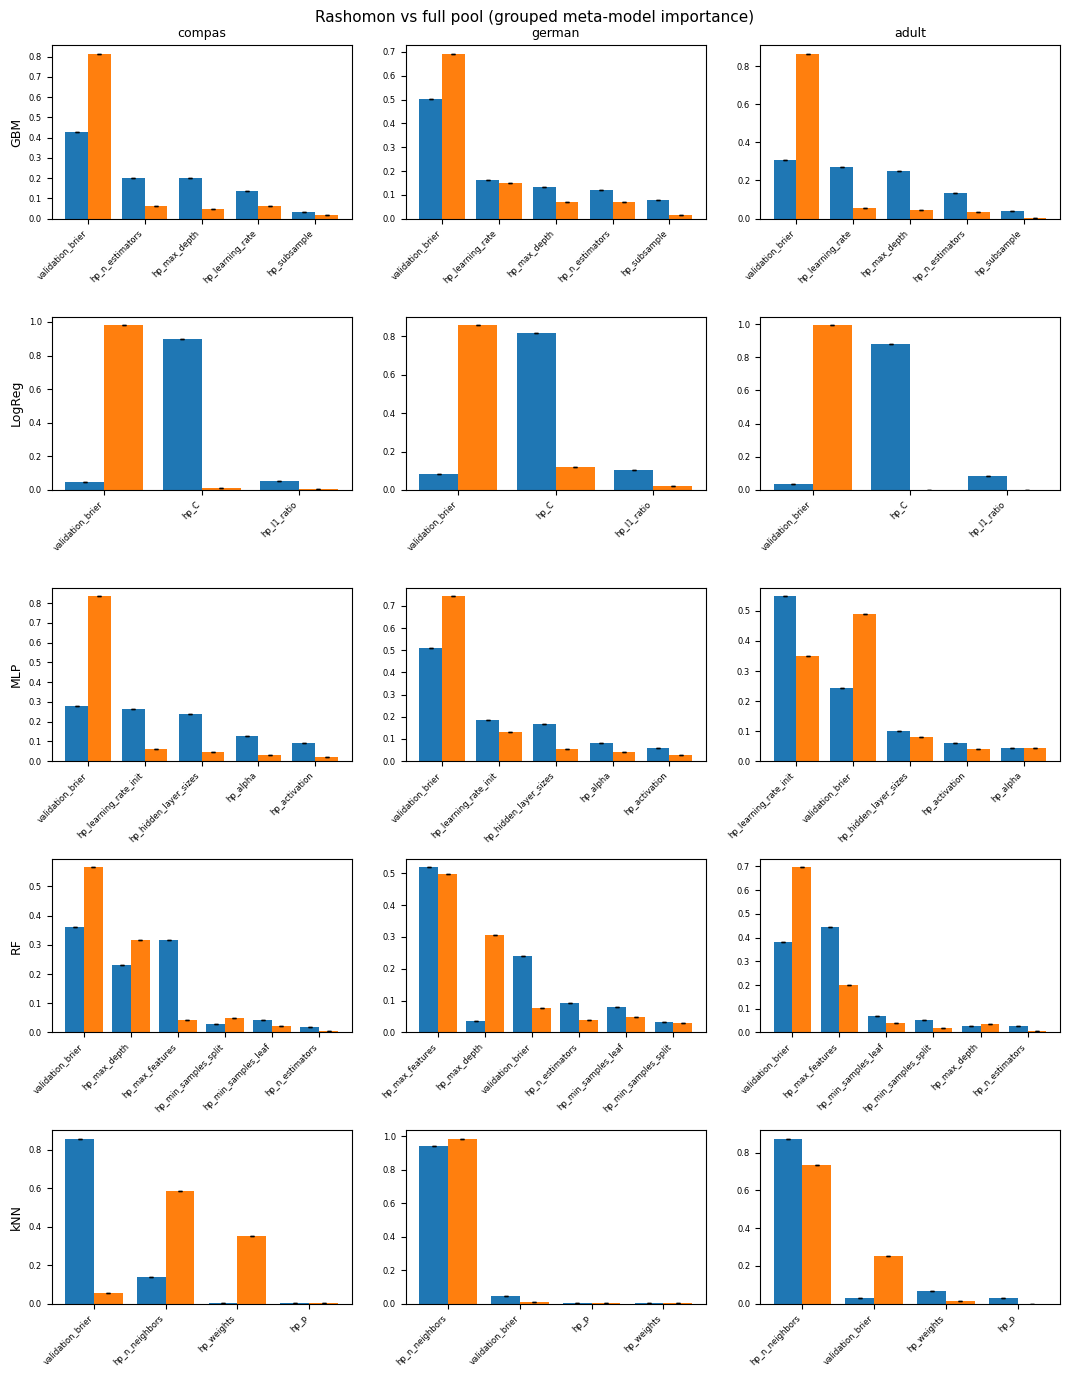

Saved hp_importance_compare_grid.pdf + per-(dataset,family) PDFs.


In [27]:
# Rashomon vs full pool: overview grid + per-(dataset, family) PDFs (thesis cites compas MLP)
from analysis.hp_notebook_plots import plot_pool_compare_grid

meta_sum = TABLE_DIR / "hp_meta_model_summary.csv"
if meta_sum.is_file():
    ms = pd.read_csv(meta_sum)
    tgt_ok = ms["target_vm"] == "V_m" if "target_vm" in ms.columns else True
    pairs = ms[tgt_ok][["dataset", "family"]].drop_duplicates().values.tolist()
else:
    pairs = []

def _compare_builder(ds, fam):
    import glob
    from pathlib import Path
    rash = TABLE_DIR / f"hp_meta_importance_{ds}_{fam}_Rashomon.csv"
    full = TABLE_DIR / f"hp_meta_importance_{ds}_{fam}_full_pool.csv"
    if not rash.is_file() or not full.is_file():
        return None
    r = pd.read_csv(rash).rename(columns={"feature_group": "hp_name"})
    r["mean_importance"] = r["importance"]
    r["std_importance"] = 0.0
    r["pool_type"] = POOL_TYPE_RASHOMON
    f = pd.read_csv(full).rename(columns={"feature_group": "hp_name"})
    f["mean_importance"] = f["importance"]
    f["std_importance"] = 0.0
    f["pool_type"] = POOL_TYPE_FULL_POOL
    out = pd.concat([r, f], ignore_index=True)
    out["dataset"] = ds
    out["family"] = fam
    return out[["hp_name", "mean_importance", "std_importance", "pool_type", "dataset", "family"]]

if pairs:
    plot_pool_compare_grid(
        _compare_builder,
        pairs=pairs,
        fig_dir=FIG_DIR,
        top_hp=TOP_HP,
    )
else:
    print("No meta-model summary rows for pool comparison plots.")


In [28]:
# family_importance_compare_all.pdf is written in the "Family importance" section above.